In [108]:
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np
import json
import re
import os


In [109]:
data_dir = "./data"
processed_dir = os.path.join(data_dir, "processed")


In [110]:
def load_json(path):
	with open(path, encoding="utf-8") as f:
		return json.load(f)

def load_tests(base_dir: str):
	data = defaultdict(lambda: {
		"pre": {"code": None, "full": None},
		"post": {"code": None, "full": None},
	})

	for phase in ["Pre", "Post"]:
		phase_key = phase.lower()
		phase_dir = os.path.join(base_dir, phase)

		for file in os.listdir(phase_dir):
			if not file.endswith(".json"):
				continue

			file_path = os.path.join(phase_dir, file)
			content = load_json(file_path)

			kind = "code" if "code" in file else "full"

			for user_id, user_data in content.items():
				data[user_id][phase_key][kind] = user_data

	return dict(data)


In [111]:
def parse_likert(v: str):
	m = re.match(r"AO0?(\d)", v)
	if m:
		return int(m.group(1))

	return None

def extract_data(code: dict, full: dict):
	out = {}
	items = {}

	full_keys = list(full.keys())

	for idx, (k, v) in enumerate(code.items()):
		if not k.startswith("G02Q03[SQ"):
			continue

		# extract SQ id (THIS is what you asked for)
		m = re.search(r"\[SQ(\d+)\]", k)
		if m:
			q_id = f"Q{m.group(1)}"
			out[q_id] = parse_likert(v)
			items[q_id] = full_keys[idx]

	return items, out


In [112]:
base_dir = os.path.join(processed_dir, "CarpeDiem-20-05-2025")
tests = load_tests(base_dir)


In [113]:
rows = []

for user_id, test in tests.items():
	pre_code = test["pre"]["code"]
	pre_full = test["pre"]["full"]
	post_code = test["post"]["code"]
	post_full = test["post"]["full"]

	if not all([pre_code, pre_full, post_code, post_full]):
		print("Skipping:", user_id)
		continue

	pre_items, pre_vals = extract_data(pre_code, pre_full)
	post_items, post_vals = extract_data(post_code, post_full)

	ids = list(pre_vals.keys())

	for id in ids:
		rows.append({
			"user_id": user_id,
			"id": id,
			"item": pre_items[id],
			"pre": pre_vals[id],
			"post": post_vals[id]
		})

global_df = pd.DataFrame(rows)
global_df["diff"] = global_df["post"] - global_df["pre"]

display(global_df)
	

,user_id,id,item,pre,post,diff
0,682b4a41c76d2e0023ed4b24_qjrb,Q01,¿Cómo de peligrosas consideras las siguientes ...,4,4,0
1,682b4a41c76d2e0023ed4b24_qjrb,Q02,¿Cómo de peligrosas consideras las siguientes ...,4,5,1
2,682b4a41c76d2e0023ed4b24_qjrb,Q03,¿Cómo de peligrosas consideras las siguientes ...,5,5,0
3,682b4a41c76d2e0023ed4b24_qjrb,Q04,¿Cómo de peligrosas consideras las siguientes ...,5,6,1
4,682b4a41c76d2e0023ed4b24_qjrb,Q05,¿Cómo de peligrosas consideras las siguientes ...,6,6,0
...,...,...,...,...,...,...
955,682b4a72c76d2e0023ed4d05_igbm,Q16,¿Cómo de peligrosas consideras las siguientes ...,4,3,-1
956,682b4a72c76d2e0023ed4d05_igbm,Q17,¿Cómo de peligrosas consideras las siguientes ...,5,2,-3
957,682b4a72c76d2e0023ed4d05_igbm,Q18,¿Cómo de peligrosas consideras las siguientes ...,6,1,-5
958,682b4a72c76d2e0023ed4d05_igbm,Q19,¿Cómo de peligrosas consideras las siguientes ...,1,6,5


In [114]:
item_diff_df = (
	global_df
	.groupby("id")
	# Definir cómo se reduce cada columna por grupo
	.agg(
		# Tomar el primer item
		item=("item", "first"),
		pre=("pre", "mean"),
		post=("post", "mean"),
		diff=("diff", "mean"),
	)
	.reset_index()
)

display(item_diff_df)


,id,item,pre,post,diff
0,Q01,¿Cómo de peligrosas consideras las siguientes ...,3.729167,4.520833,0.791667
1,Q02,¿Cómo de peligrosas consideras las siguientes ...,4.229167,4.729167,0.500000
2,Q03,¿Cómo de peligrosas consideras las siguientes ...,3.500000,4.416667,0.916667
3,Q04,¿Cómo de peligrosas consideras las siguientes ...,4.416667,4.833333,0.416667
4,Q05,¿Cómo de peligrosas consideras las siguientes ...,4.916667,4.875000,-0.041667
5,Q06,¿Cómo de peligrosas consideras las siguientes ...,4.354167,4.708333,0.354167
6,Q07,¿Cómo de peligrosas consideras las siguientes ...,4.875000,5.083333,0.208333
7,Q08,¿Cómo de peligrosas consideras las siguientes ...,4.833333,4.958333,0.125000
8,Q09,¿Cómo de peligrosas consideras las siguientes ...,4.083333,4.708333,0.625000
9,Q10,¿Cómo de peligrosas consideras las siguientes ...,3.895833,4.687500,0.791667


In [115]:
id_to_keyword = {
	"Q01": "perfil público",
	"Q02": "aceptar desconocidos",
	"Q03": "grupos públicos",
	"Q04": "chat con desconocidos",
	"Q05": "videollamada desconocidos",
	"Q06": "amistad desconocidos",
	"Q07": "quedar en persona",
	"Q08": "hablar con adultos online",
	"Q09": "foto de cara",
	"Q10": "fotos de amigos",
	"Q11": "foto en bañador",
	"Q12": "sexualidad pública",
	"Q13": "teléfono público",
	"Q14": "nombre completo",
	"Q15": "edad/cumpleaños",
	"Q16": "centro de estudios",
	"Q17": "país",
	"Q18": "provincia",
	"Q19": "calle",
	"Q20": "dirección casa"
}

item_diff_df["keyword"] = item_diff_df["id"].map(id_to_keyword)

display(item_diff_df)


,id,item,pre,post,diff,keyword
0,Q01,¿Cómo de peligrosas consideras las siguientes ...,3.729167,4.520833,0.791667,perfil público
1,Q02,¿Cómo de peligrosas consideras las siguientes ...,4.229167,4.729167,0.500000,aceptar desconocidos
2,Q03,¿Cómo de peligrosas consideras las siguientes ...,3.500000,4.416667,0.916667,grupos públicos
3,Q04,¿Cómo de peligrosas consideras las siguientes ...,4.416667,4.833333,0.416667,chat con desconocidos
4,Q05,¿Cómo de peligrosas consideras las siguientes ...,4.916667,4.875000,-0.041667,videollamada desconocidos
5,Q06,¿Cómo de peligrosas consideras las siguientes ...,4.354167,4.708333,0.354167,amistad desconocidos
6,Q07,¿Cómo de peligrosas consideras las siguientes ...,4.875000,5.083333,0.208333,quedar en persona
7,Q08,¿Cómo de peligrosas consideras las siguientes ...,4.833333,4.958333,0.125000,hablar con adultos online
8,Q09,¿Cómo de peligrosas consideras las siguientes ...,4.083333,4.708333,0.625000,foto de cara
9,Q10,¿Cómo de peligrosas consideras las siguientes ...,3.895833,4.687500,0.791667,fotos de amigos


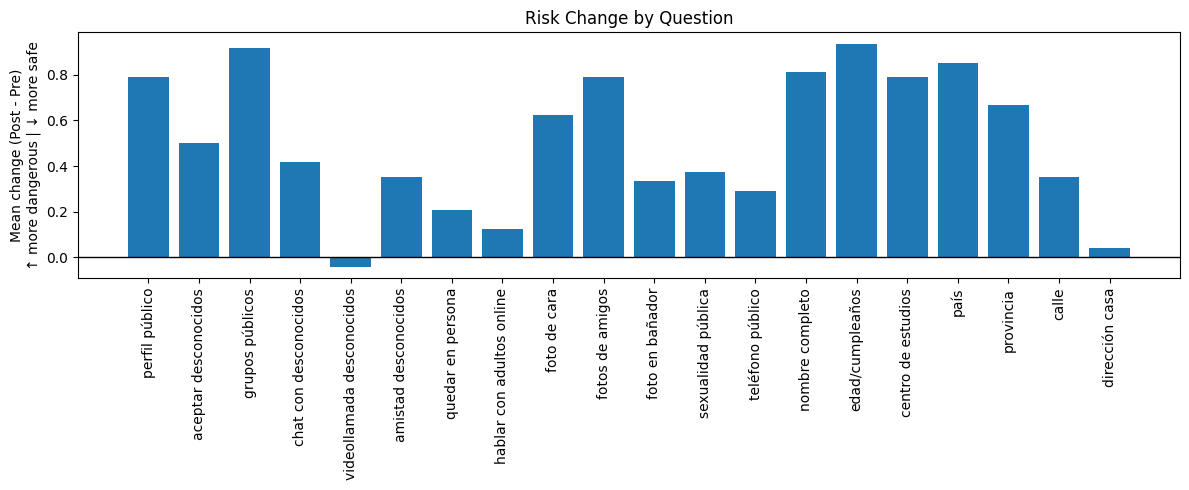

In [122]:
plt.figure(figsize=(12, 5))

plt.bar(item_diff_df["keyword"], item_diff_df["diff"])

plt.axhline(0, color="black", linewidth=1)

plt.xticks(rotation=90)
plt.ylabel("Mean change (Post - Pre)\n↑ more dangerous | ↓ more safe")
plt.title("Risk Change by Question")

plt.tight_layout()
plt.show()


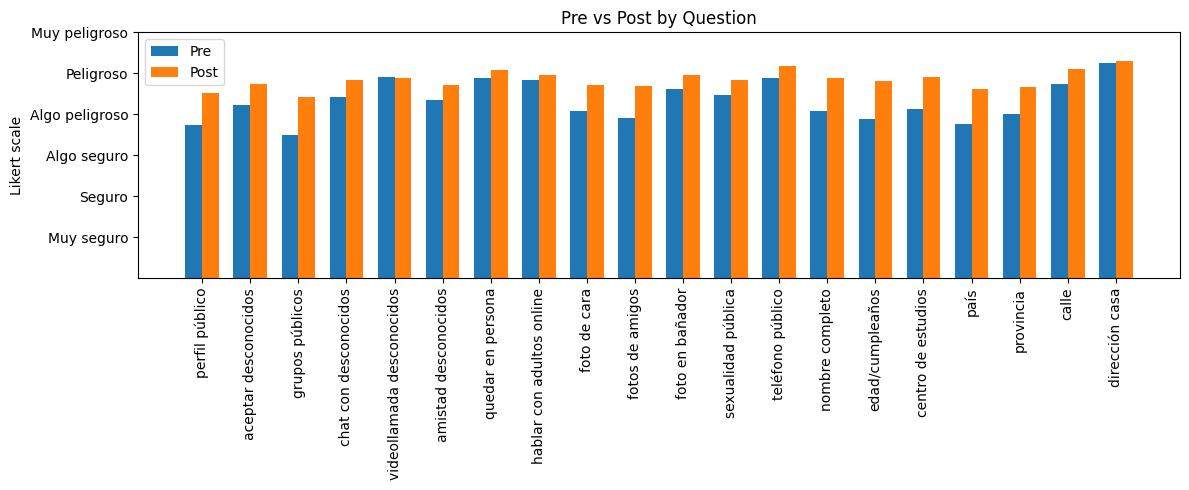

In [123]:
likert_labels = {
	1: "Muy seguro",
	2: "Seguro",
	3: "Algo seguro",
	4: "Algo peligroso",
	5: "Peligroso",
	6: "Muy peligroso"
}

x = np.arange(len(item_diff_df))
width = 0.35

plt.figure(figsize=(12, 5))

plt.bar(x - width/2, item_diff_df["pre"], width, label="Pre")
plt.bar(x + width/2, item_diff_df["post"], width, label="Post")

plt.xticks(x, item_diff_df["keyword"], rotation=90)
plt.yticks(list(likert_labels.keys()), list(likert_labels.values()))

plt.ylabel("Likert scale")
plt.title("Pre vs Post by Question")
plt.legend()

plt.tight_layout()
plt.show()
